In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import joblib

In [4]:
#Loading dataset
df = pd.read_csv("E:\Explainable-Fraud-Detection-System\dataset\creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
#Basic info
print(df.shape)
print(df["Class"].value_counts())
#fraud cases are VERY less (imbalance problem)

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [6]:
#Feature Scaling
scaler = StandardScaler()
df["Amount"] = scaler.fit_transform(df[["Amount"]])

In [7]:
#Split Data
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
#Handle imbalance
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_res).value_counts())

Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


In [9]:
#Training XGBoost Model
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    scale_pos_weight=10,
    random_state=42
)

model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [10]:
#Evaluate Model
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.52      0.89      0.65        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.984908675766311


In [11]:
#Save Model
joblib.dump(model, "E:\Explainable-Fraud-Detection-System\model\model.pkl")

['E:\\Explainable-Fraud-Detection-System\\model\\model.pkl']

In [12]:
#Risk Score Column
results = X_test.copy()
results["Actual"] = y_test
results["Predicted"] = y_pred
results["Fraud_Probability"] = y_prob

results.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Actual,Predicted,Fraud_Probability
263020,160760.0,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,...,-0.224327,0.707899,-0.135837,0.045102,0.533837,0.291319,-0.261273,0,0,0.000670
11378,19847.0,-2.829816,-2.765149,2.537793,-1.074580,2.842559,-2.153536,-1.795519,-0.250020,3.073504,...,-0.813272,0.042996,-0.027660,-0.910247,0.110802,-0.511938,-0.305852,0,0,0.000025
147283,88326.0,-3.576495,2.318422,1.306985,3.263665,1.127818,2.865246,1.444125,-0.718922,1.874046,...,-0.132058,-1.483996,-0.296011,0.062823,0.552411,0.509764,-0.049095,0,0,0.000128
219439,141734.0,2.060386,-0.015382,-1.082544,0.386019,-0.024331,-1.074935,0.207792,-0.338140,0.455091,...,0.331818,-0.067584,-0.283675,0.203529,-0.063621,-0.060077,-0.349271,0,0,0.000012
36939,38741.0,1.209965,1.384303,-1.343531,1.763636,0.662351,-2.113384,0.854039,-0.475963,-0.629658,...,-0.154631,0.619449,0.818998,-0.330525,0.046884,0.104527,-0.347232,0,0,0.000414


In [13]:
%pip install shap

In [14]:
import shap

# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)

In [15]:
#Compute SHAP values

# Use small sample (important for speed ⚡)
X_sample = X_test.sample(100, random_state=42)

shap_values = explainer.shap_values(X_sample)

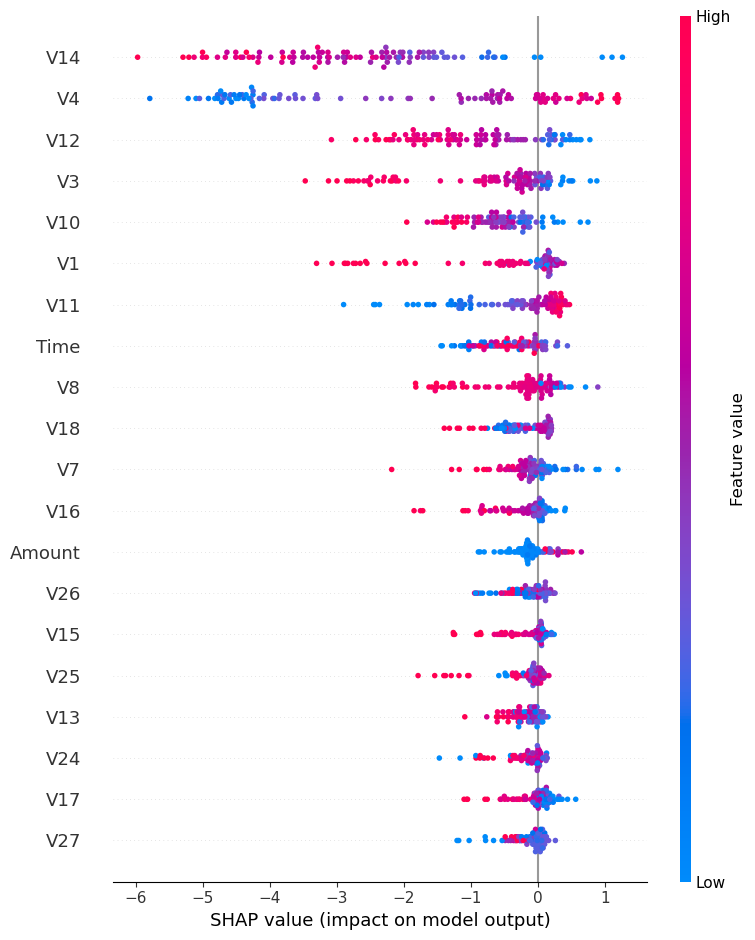

In [16]:
#Global Feature Importance
shap.summary_plot(shap_values, X_sample)

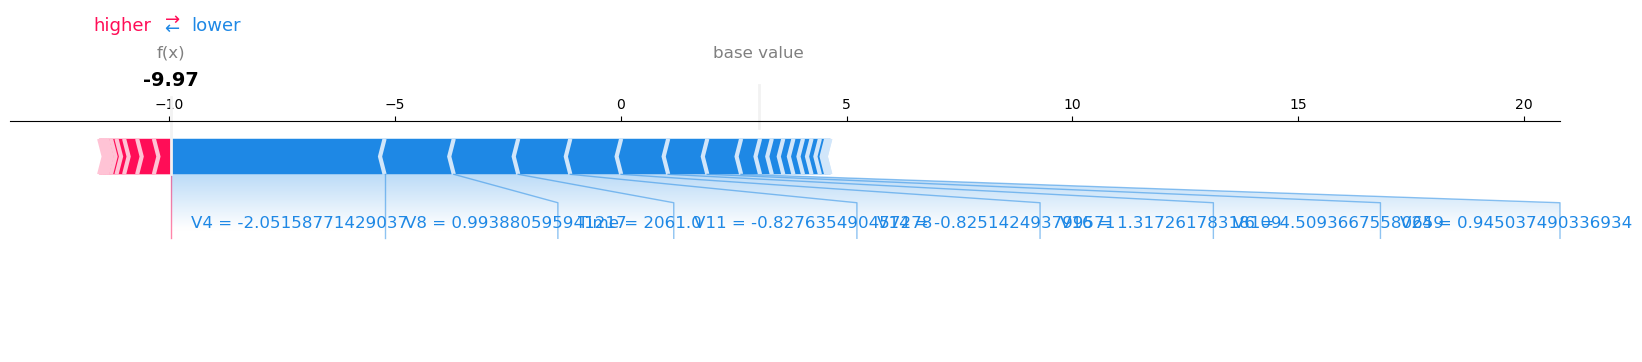

In [17]:
#Local Explanation
# Explain one transaction
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_sample.iloc[0],
    matplotlib=True
)

In [22]:
import shap
import matplotlib.pyplot as plt

# small sample (important)
X_sample = X_test.sample(100, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# save image
shap.summary_plot(shap_values, X_sample, show=False)
plt.savefig("E:\Explainable-Fraud-Detection-System\images\shap_summary.png", bbox_inches='tight')
plt.close()